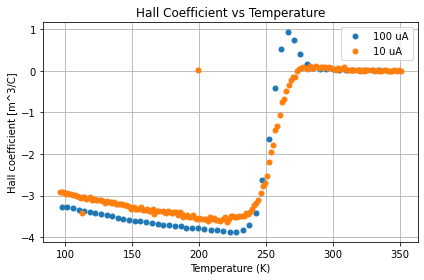

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Semiconductor Dimensions
width = 10.0/100
length = 10.0/100
thickness = 1.25/1000
cross_area = width * thickness
q = 1.602e-19


df_100uA = pd.read_csv("2000G100uA.txt", sep="\t", engine="python")
df_10uA = pd.read_csv("2000G10uA.txt", sep="\t", engine="python")

# Convert required columns to numeric
cols_to_convert = ["Temperature (K)", "Voltage AC", "Voltage BD", "B-Field (Gauss)"]
for col in cols_to_convert:
    df_2000G[col] = pd.to_numeric(df_2000G[col], errors="coerce")

# Drop rows with missing values in any of those columns
df_2000G = df_2000G.dropna(subset=cols_to_convert)

# Split the data into three B-field ranges
df100 = df_100uA[(df_100uA["B-Field (Gauss)"] >= -1000) & (df_100uA["B-Field (Gauss)"] <= 1000)].copy()
df10 = df_10uA[(df_10uA["B-Field (Gauss)"] >= -1000) & (df_10uA["B-Field (Gauss)"] <= 1000)].copy()

for df in [df100, df10]:
    df["1/T (1/K)"] = 1 / pd.to_numeric(df["Temperature (K)"])
    df["B (T)"] = df["B-Field (Gauss)"] / 1e4
    df["V_rho"] = 0.5 * (df["Voltage DC"] - df["Voltage -DC"])
    df["V_hall"] = 0.5 * ((0.5 * (df["Voltage BD"] - df["Voltage -BD"])) + (0.5 * (df["Voltage AC"] - df["Voltage -AC"])))
    
df100_B_zero = df100[["Temperature (K)", "1/T (1/K)", "V_rho", "V_hall", "B (T)"]].to_numpy()
df10_B_zero = df10[["Temperature (K)", "1/T (1/K)", "V_rho", "V_hall", "B (T)"]].to_numpy()


zero_temp100 = df100_B_zero[:, 0]
zeroinv_temp100 = df100_B_zero[:, 1]
zerov_rho100 = df100_B_zero[:, 2]
zerov_hall100 = df100_B_zero[:, 3]
zerob_field100 = df100_B_zero[:, 4]

zero_temp10 = df10_B_zero[:, 0]
zeroinv_temp10 = df10_B_zero[:, 1]
zerov_rho10 = df10_B_zero[:, 2]
zerov_hall10 = df10_B_zero[:, 3]
zerob_field10 = df10_B_zero[:, 4]

# Compute physical quantities - Zero
zero_resis100 = np.abs((zerov_rho100*0.01 * cross_area) / (100e-6 * length))
zero_conduc100 = 1 / zero_resis100
zero_RH100 = (zerov_hall100 * thickness) / (100e-6 * zerob_field100)

zero_resis10 = np.abs((zerov_rho10*0.01 * cross_area) / (10e-6 * length))
zero_conduc10 = 1 / zero_resis10
zero_RH10 = (zerov_hall10 * thickness) / (10e-6 * zerob_field10)


plt.plot(zero_temp100, zero_RH100, 'o', ms=5, label='100 uA')
plt.plot(zero_temp10, zero_RH10, 'o', ms=5, label='10 uA')
plt.xlabel("Temperature (K)")
plt.ylabel("Hall coefficient [m^3/C]")
plt.title('Hall Coefficient vs Temperature')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
